# 🔍 Retrieval Benchmarks
Comparing Dense vs BM25 vs Hybrid retrieval strategies on aerospace maintenance queries.

In [ ]:
import os
import sys

# Directly set to your project root
PROJECT_ROOT = r"path_to_your_root"
os.chdir(PROJECT_ROOT)
sys.path.insert(0, PROJECT_ROOT)
print(os.getcwd())  
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
from rank_bm25 import BM25Okapi
import numpy as np

from src.embeddings.vector_store import load_index
from src.ingestion.pdf_loader import load_all_documents
from src.ingestion.chunker import pages_to_langchain_docs, chunk_documents
from src.retrieval.hybrid_search import HybridRetriever

sns.set_theme(style='darkgrid')
print('Loading index and chunks...')
vs = load_index()
pages = load_all_documents(data_dir='data/raw')
docs = pages_to_langchain_docs(pages)
chunks = chunk_documents(docs)
print('Ready!')

c:\Users\Karthik\Desktop\Projects\aeromanual-rag\venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
INFO:src.embeddings.vector_store:Loading embedding model: BAAI/bge-base-en-v1.5


Loading index and chunks...


INFO:datasets:PyTorch version 2.4.0 available.
INFO:sentence_transformers.SentenceTransformer:Load pretrained SentenceTransformer: BAAI/bge-base-en-v1.5
INFO:faiss.loader:Loading faiss with AVX2 support.
INFO:faiss.loader:Successfully loaded faiss with AVX2 support.
INFO:src.ingestion.pdf_loader:Loaded 1050 pages from faa_airframe
INFO:src.ingestion.pdf_loader:Loaded 674 pages from faa_general
INFO:src.ingestion.pdf_loader:Loaded 499 pages from faa_powerplant
INFO:src.ingestion.pdf_loader:Total pages loaded: 2223
INFO:src.ingestion.chunker:Created 18223 chunks from 2223 pages


Ready!


## 1. Test Queries

In [6]:
TEST_QUERIES = [
    'turbine engine hot section inspection',
    'magneto timing reciprocating engine',
    'hydraulic system maintenance landing gear',
    'fuel system safety precautions',
    'compression test cylinder',
    'corrosion treatment prevention aircraft',
    'control cable inspection broken wires',
    'propeller inspection nicks cracks',
    'battery maintenance electrolyte',
    'NDT nondestructive testing methods'
]
print(f'{len(TEST_QUERIES)} test queries ready')

10 test queries ready


## 2. Compare Retrieval Latency

In [7]:
# Dense retriever
dense_retriever = vs.as_retriever(search_kwargs={'k': 5})

# BM25 retriever
tokenized = [doc.page_content.lower().split() for doc in chunks]
bm25 = BM25Okapi(tokenized)

# Hybrid retriever
hybrid = HybridRetriever(vs, chunks, k=5)

results = []
for query in TEST_QUERIES:
    # Dense
    t0 = time.time()
    dense_docs = dense_retriever.invoke(query)
    dense_time = time.time() - t0

    # BM25
    t0 = time.time()
    tokens = query.lower().split()
    scores = bm25.get_scores(tokens)
    top_idx = np.argsort(scores)[::-1][:5]
    bm25_time = time.time() - t0

    # Hybrid
    t0 = time.time()
    hybrid_docs = hybrid.retrieve(query)
    hybrid_time = time.time() - t0

    results.append({
        'query': query[:40],
        'dense_ms': dense_time * 1000,
        'bm25_ms': bm25_time * 1000,
        'hybrid_ms': hybrid_time * 1000,
        'dense_sources': len(set([d.metadata['source'] for d in dense_docs])),
        'hybrid_sources': len(set([d.metadata['source'] for d in hybrid_docs]))
    })

df = pd.DataFrame(results)
print(df[['query', 'dense_ms', 'bm25_ms', 'hybrid_ms']].to_string())

INFO:src.retrieval.hybrid_search:Building BM25 index...
INFO:src.retrieval.hybrid_search:HybridRetriever ready


                                      query     dense_ms    bm25_ms   hybrid_ms
0     turbine engine hot section inspection  1459.339142  33.745050  102.456093
1       magneto timing reciprocating engine    77.818632  32.926798   98.844528
2  hydraulic system maintenance landing gea    49.378157  36.213636   82.468748
3            fuel system safety precautions    48.083305  32.046556   79.981565
4                 compression test cylinder    53.172112   5.900145   69.822550
5   corrosion treatment prevention aircraft    62.318563  18.500090   84.374905
6     control cable inspection broken wires    58.761120  25.568962   80.676556
7         propeller inspection nicks cracks    66.779852  17.974854   80.567837
8           battery maintenance electrolyte    68.746805  16.006947   77.772617
9        NDT nondestructive testing methods    68.382740  16.032457   80.990553


## 3. Latency Comparison Chart

C:\Users\Karthik\AppData\Local\Temp\ipykernel_35176\1913227659.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=avg_latency, x='Method', y='Avg Latency (ms)', palette='Set2', ax=axes[0])
C:\Users\Karthik\AppData\Local\Temp\ipykernel_35176\1913227659.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=avg_sources, x='Method', y='Avg Unique Sources', palette='Set1', ax=axes[1])


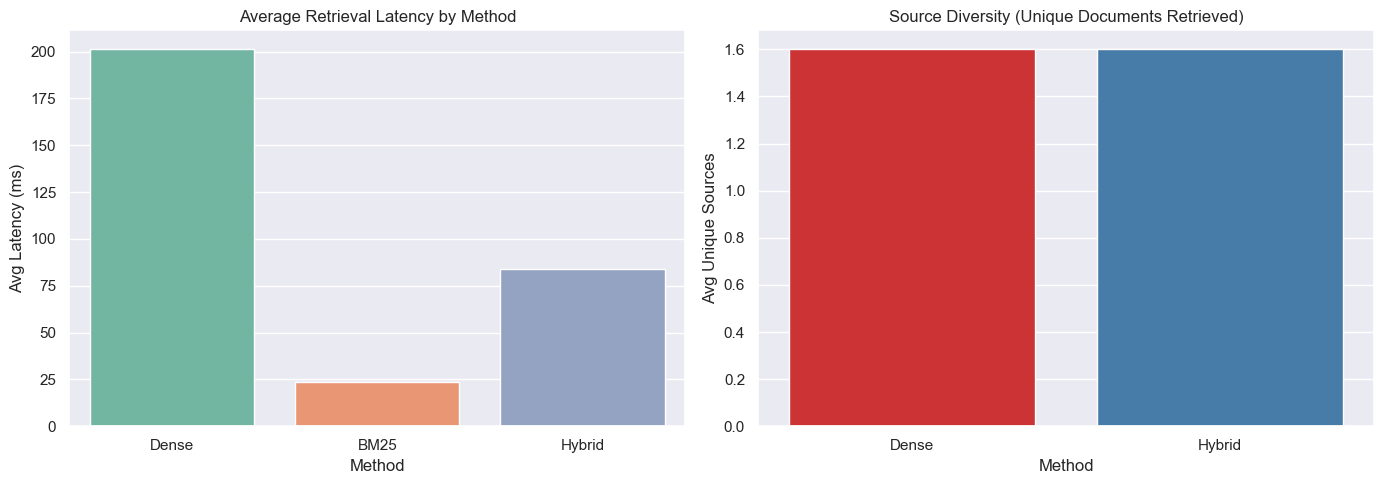

Dense avg latency  : 201.3ms
BM25 avg latency   : 23.5ms
Hybrid avg latency : 83.8ms


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Latency comparison
avg_latency = pd.DataFrame({
    'Method': ['Dense', 'BM25', 'Hybrid'],
    'Avg Latency (ms)': [df['dense_ms'].mean(), df['bm25_ms'].mean(), df['hybrid_ms'].mean()]
})
sns.barplot(data=avg_latency, x='Method', y='Avg Latency (ms)', palette='Set2', ax=axes[0])
axes[0].set_title('Average Retrieval Latency by Method')

# Source diversity
avg_sources = pd.DataFrame({
    'Method': ['Dense', 'Hybrid'],
    'Avg Unique Sources': [df['dense_sources'].mean(), df['hybrid_sources'].mean()]
})
sns.barplot(data=avg_sources, x='Method', y='Avg Unique Sources', palette='Set1', ax=axes[1])
axes[1].set_title('Source Diversity (Unique Documents Retrieved)')

plt.tight_layout()
plt.savefig('data/processed/retrieval_benchmark.png', dpi=150)
plt.show()

print(f'Dense avg latency  : {df["dense_ms"].mean():.1f}ms')
print(f'BM25 avg latency   : {df["bm25_ms"].mean():.1f}ms')
print(f'Hybrid avg latency : {df["hybrid_ms"].mean():.1f}ms')